In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from scipy.stats import norm

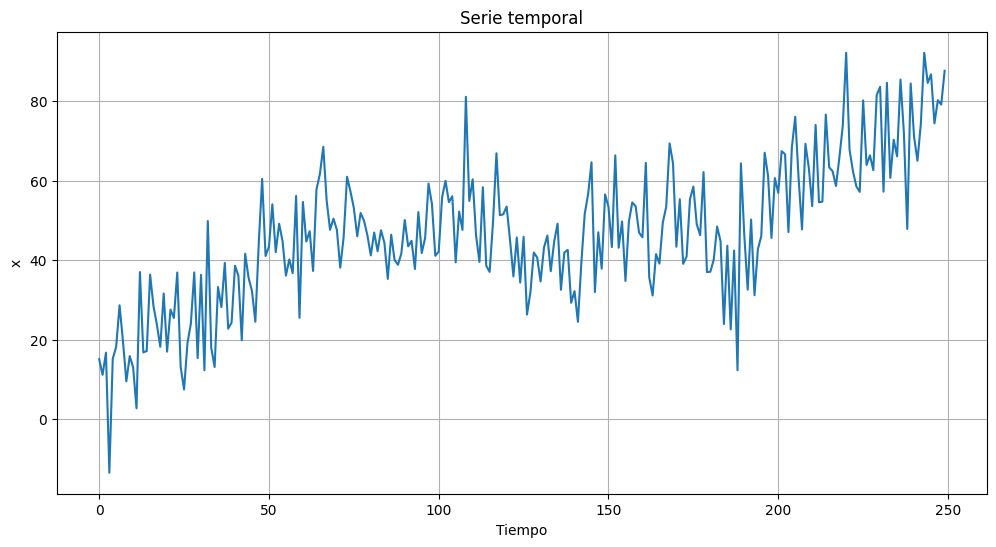

In [161]:
# Parametros
N = 250
tiempo = np.arange(N)  # 0 to N-1
slope = 0.3
intercept = 10

# Construccion de señal
np.random.seed(1310)
noise = np.random.normal(scale=10, size=N)
serie = (15 * np.sin(2 * np.pi * tiempo / N) +  # componente sinuidal de 1 ciclo y amplitud 15
         5 * np.sin(5 * 2 * np.pi * tiempo / N) +  # componente sinuidal de 5 ciclos y amplitud 5
         noise +  # ruido
         slope * tiempo + intercept)                           # trend lineal

# Plot
plt.figure(figsize=(12, 6))
plt.plot(tiempo, serie, linestyle='-')
plt.title('Serie temporal')
plt.xlabel('Tiempo')
plt.ylabel('x')
plt.grid(True)
plt.show()

## Test de Estacionalidad

In [163]:
def check_estacionalidad(serie):
    # Prueba ADF
    adf_result = adfuller(serie)
    print('ADF Statistic:', adf_result[0])
    print('p-value:', adf_result[1])
    print('Used Lag:', adf_result[2])
    print('Number of Observations Used:', adf_result[3])
    print('Critical Values:', adf_result[4])
    print('')

    # Prueba KPSS
    kpss_result = kpss(serie, regression='c', nlags='auto')
    print('KPSS Statistic:', kpss_result[0])
    print('p-value:', kpss_result[1])
    print('Lags Used:', kpss_result[2])
    print('Critical Values:', kpss_result[3])
    print('')

    adf_p = adf_result[1]
    kpss_p = kpss_result[1]

    # Decisión sobre estacionariedad
    if adf_p < 0.05 and kpss_p >= 0.05:
        decision = "Estacionaria"
    elif adf_p < 0.05 and kpss_p < 0.05:
        decision = "Indefinida"
    elif adf_p >= 0.05 and kpss_p >= 0.05:
        decision = "Indefinida"
    elif adf_p >= 0.05 and kpss_p < 0.05:
        decision = "No estacionaria"
    else:
        decision = "Indefinida"

    print("Decisión:", decision)

check_estacionalidad(serie)

ADF Statistic: -1.1869190457181251
p-value: 0.6791973441419609
Used Lag: 6
Number of Observations Used: 243
Critical Values: {'1%': np.float64(-3.4575505077947746), '5%': np.float64(-2.8735087323013526), '10%': np.float64(-2.573148434859185)}

KPSS Statistic: 1.7089096176630256
p-value: 0.01
Lags Used: 9
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

Decisión: No estacionaria


/tmp/ipykernel_30050/2345367936.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(serie, regression='c', nlags='auto')


Una serie es estacionaria si sus propiedades estadísticas (media, varianza, autocorrelación) no cambian con el tiempo. En particular, no debe tener una tendencia determinista ni una varianza creciente.

En nuestro caso, el término de la slope introduce una componente lineal creciente, con lo cual la media cambia en el tiempo (crece constantemente), rompiendo la estacionariedad, ya que no "oscila alrededor de una media constante".

## Forecasting Lineal

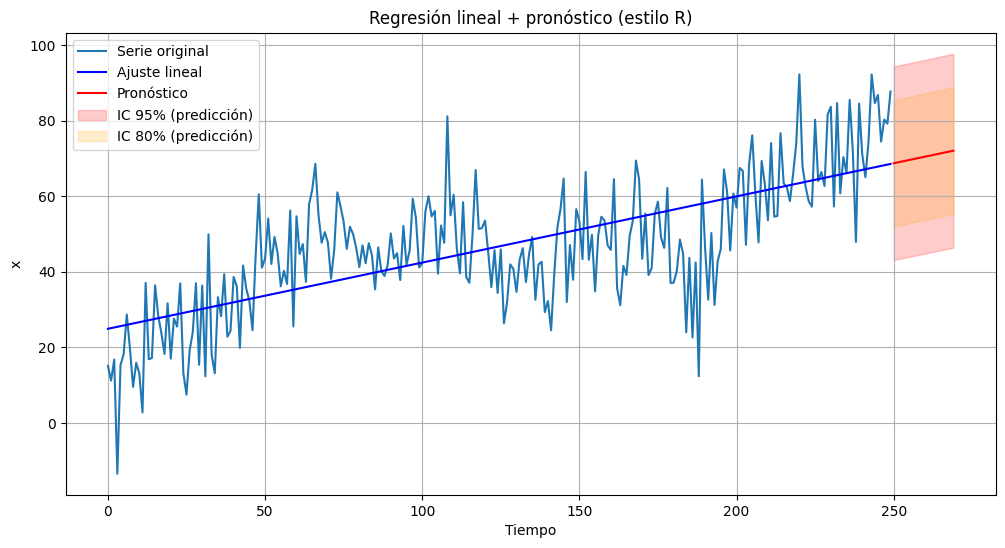

In [164]:
# Ajuste lineal
X = sm.add_constant(tiempo)
model = sm.OLS(serie, X).fit()

# Predicción futura
h = 20
tiempo_futuro = np.arange(N, N + h)
X_futuro = sm.add_constant(tiempo_futuro)
pred = model.get_prediction(X_futuro)
pred_95_df = pred.summary_frame(alpha=0.05)  # 95% por defecto
pred_80_df = pred.summary_frame(alpha=0.20)  # 80% por defecto

# Plot
plt.figure(figsize=(12, 6))
plt.plot(tiempo, serie, label='Serie original')
plt.plot(tiempo, model.fittedvalues, color='blue', label='Ajuste lineal')
plt.plot(tiempo_futuro, pred_95_df['mean'], color='red', label='Pronóstico')

# Intervalos de predicción (como forecast::forecast en R)
plt.fill_between(tiempo_futuro, pred_95_df['obs_ci_lower'], pred_95_df['obs_ci_upper'],
                 color='red', alpha=0.2, label='IC 95% (predicción)')
plt.fill_between(tiempo_futuro, pred_80_df['obs_ci_lower'], pred_80_df['obs_ci_upper'],
                 color='orange', alpha=0.2, label='IC 80% (predicción)')

plt.xlabel('Tiempo')
plt.ylabel('x')
plt.title('Regresión lineal + pronóstico (estilo R)')
plt.legend()
plt.grid(True)
plt.show()

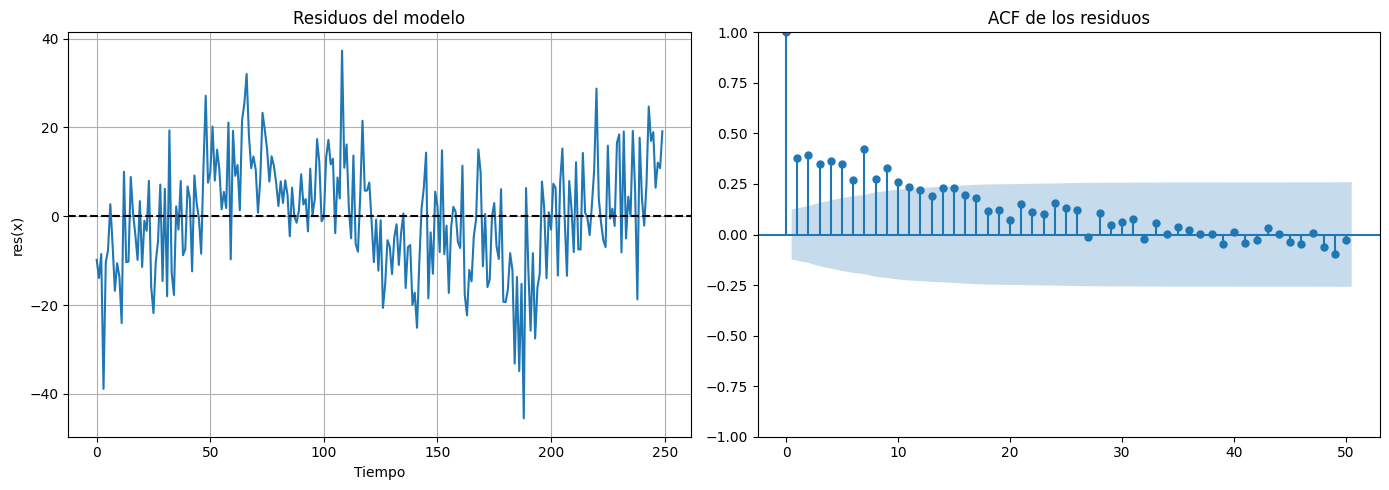

In [172]:
# Residuos
residuos = model.resid

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Residuos como serie temporal
axes[0].plot(residuos)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Residuos del modelo')
axes[0].set_ylabel('res(x)')
axes[0].set_xlabel('Tiempo')
axes[0].grid(True)

# Panel 2: Función de autocorrelación
plot_acf(residuos, ax=axes[1], lags=50, alpha=.05)
axes[1].set_title('ACF de los residuos')

plt.tight_layout()
plt.show()

Se observa una autocorrelación significativa en los residuos del modelo de regresión lineal, particularmente en los lags del 1 al 15, donde las barras de la función de autocorrelación (ACF) superan las bandas de significancia (representadas en azul) con umbral de significancia de 95%. Luego, entre los lagas 10 y 25, si bien no son significativos, son bastante altos para ser considerados simple ruido.

Esto indica que los residuos no se comportan como ruido blanco, es decir, no son completamente aleatorios. En cambio, existe una estructura temporal no explicada por el modelo lineal. En lags más alejados (a partir del lag 25), se observa una baja correlación, lo que sugiere la presencia de ruido.

Por lo tanto, podemos concluir que la serie está compuesta por componentes periódicos y ruido. La ACF sugiere que:

- La regresión lineal no logra capturar toda la dinámica temporal de la serie.
- Persisten patrones dependientes en el tiempo que el modelo no considera.
- Es probable que existan componentes cíclicos, estacionales o autoregresivos que no fueron modelados.

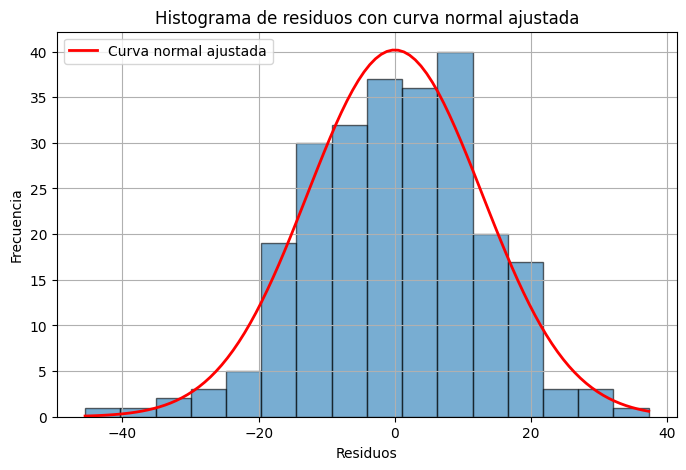

In [173]:
# Histograma de residuos
plt.figure(figsize=(8,5))
count, bins, ignored = plt.hist(residuos, bins='fd', density=False, alpha=0.6, edgecolor='black')

# Ajuste de distribución normal con media y desviación estándar de residuos
mu, std = residuos.mean(), residuos.std()

# Valores x para la curva normal
x = np.linspace(bins[0], bins[-1], 100)

# Escalamos la curva normal para que coincida con el histograma (multiplicamos por el total y el ancho del bin)
scale = len(residuos) * np.diff(bins)[0]  # cantidad de datos * ancho del bin

plt.plot(x, scale * norm.pdf(x, mu, std), 'r-', lw=2, label='Curva normal ajustada')

plt.title('Histograma de residuos con curva normal ajustada')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)
plt.show()

El histograma de residuos se ajusta bien a la curva normal, lo cual sugiere que los residuos están distribuidos de manera aleatoria, sin patrones sistemáticos, y que **el modelo está capturando bien la tendencia subyacente de los datos**. Esto es una señal de que la estimación con una recta en nuestro modelo de regresión lineal es adecuada.

## Descomposición

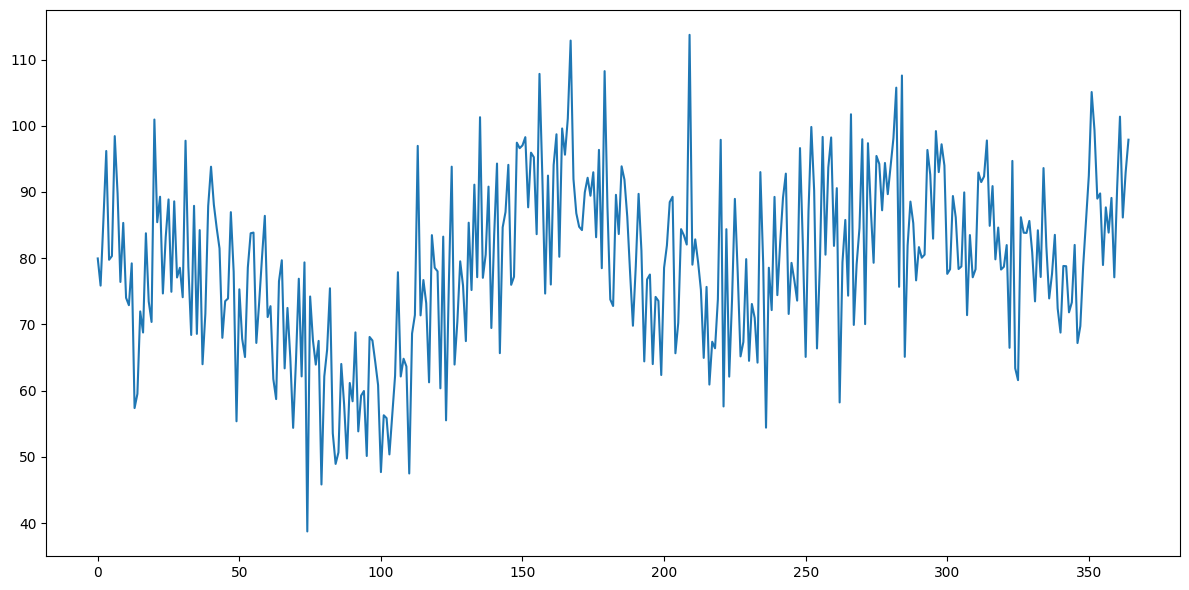

In [205]:
# Parámetros
N = 365  # mismo número de meses que tiene elecequip (1985-01 a 2008-07)
tiempo = np.arange(N)
slope = 0.05
intercept = 70

# Construcción de la señal
np.random.seed(42)
noise = np.random.normal(scale=10, size=N)
serie = (10 * np.sin(3 * 2 * np.pi * tiempo / N) +
         5 * np.cos(2 * 2 * np.pi * tiempo / N) +
         5 * np.sin(20 * 2 * np.pi * tiempo / N) +
         noise +                                   # ruido
         slope * tiempo + intercept)               # tendencia lineal

plt.figure(figsize=(12, 6))
plt.plot(tiempo, serie, label='Serie original')
plt.tight_layout()
plt.show()

In [206]:
check_estacionalidad(serie)

ADF Statistic: -3.1237133161016675
p-value: 0.02484734619134239
Used Lag: 5
Number of Observations Used: 359
Critical Values: {'1%': np.float64(-3.4486972813047574), '5%': np.float64(-2.8696246923288418), '10%': np.float64(-2.571077032068342)}

KPSS Statistic: 0.858069455048483
p-value: 0.01
Lags Used: 10
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

Decisión: Indefinida


/tmp/ipykernel_30050/2345367936.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(serie, regression='c', nlags='auto')


### Descomposición clásica

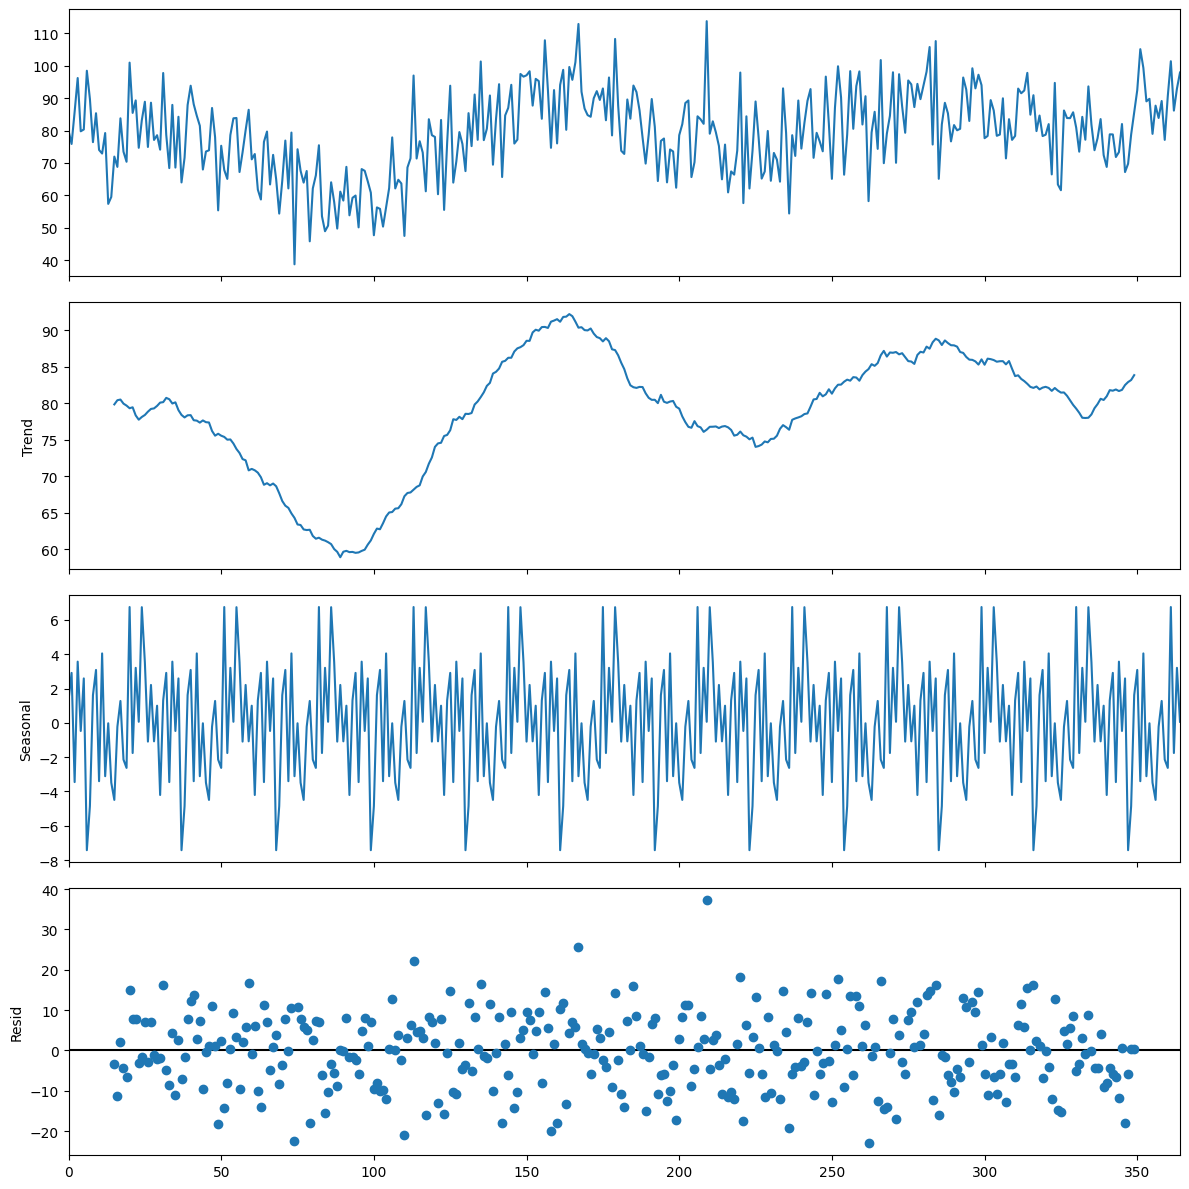

In [207]:
serie_pd = pd.Series(serie, index=tiempo)
periodo = 31

# Elijo periodo 31 para ver trend mensual (es un moving average)
decomposed = seasonal_decompose(serie_pd, model='additive', period=periodo)

# Plot
plt.rcParams.update({'figure.figsize': (12, 12)})
decomposed.plot()
plt.tight_layout()
plt.show()

## Descomposición STL

Similar a la clásica, pero en vez de usar Medias Móviles como la clásica, usa LOESS, por lo que tiene suavizado.
La clásica es más para estacionalidad fija y conocida, mientras que STL puede tener estacionalidades cambiantes en el tiempo.

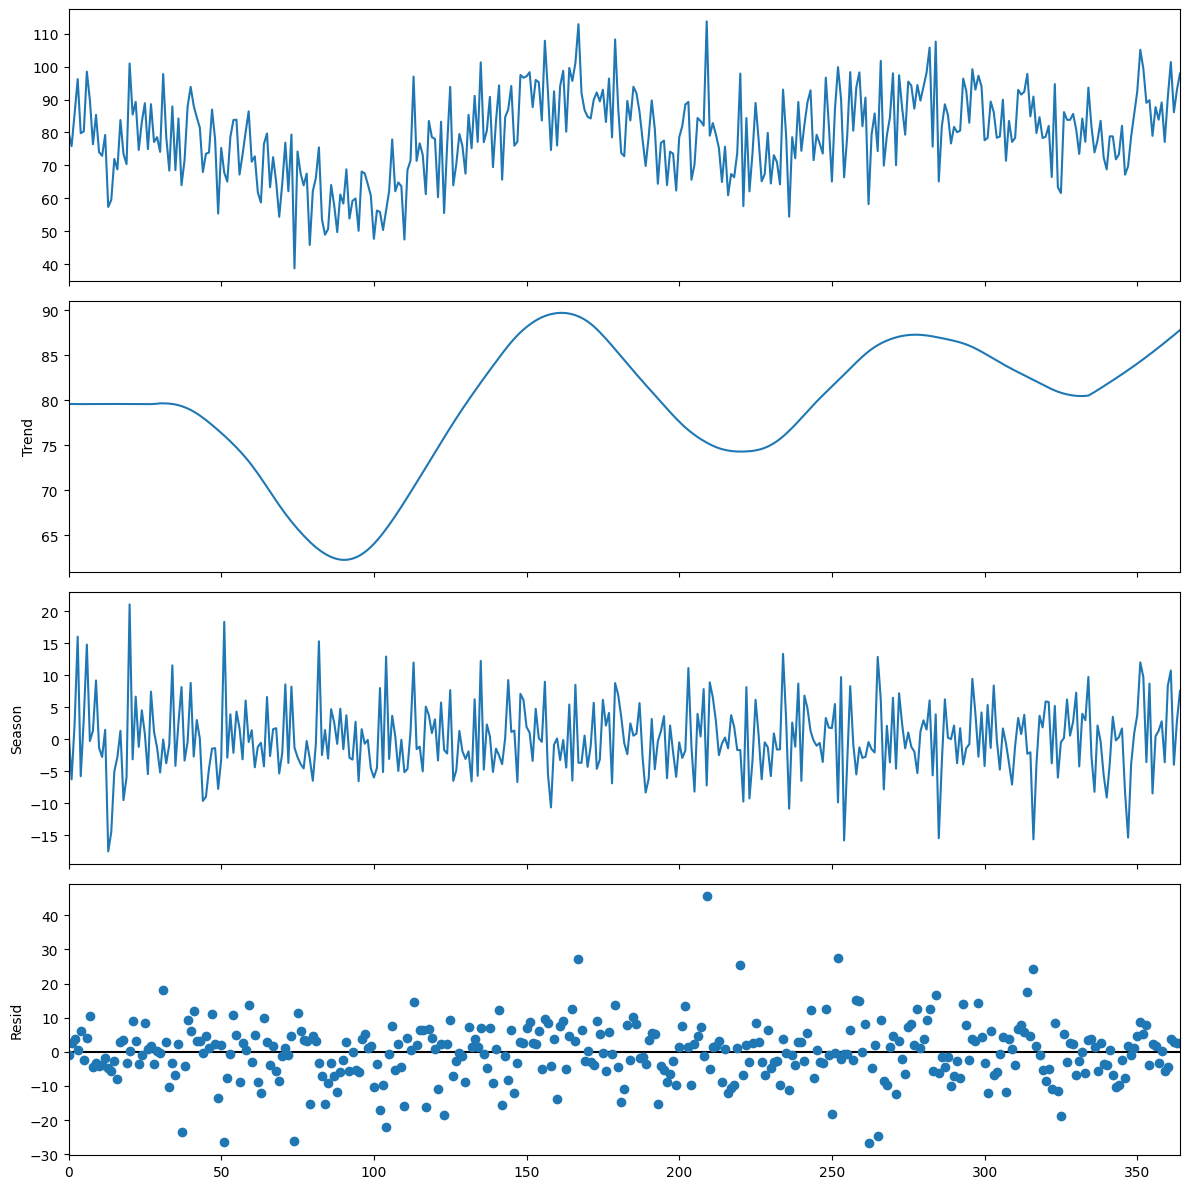

In [208]:
stl = STL(serie_pd, period=periodo, robust=True)
res = stl.fit()

# Graficar
res.plot()
plt.tight_layout()
plt.show()

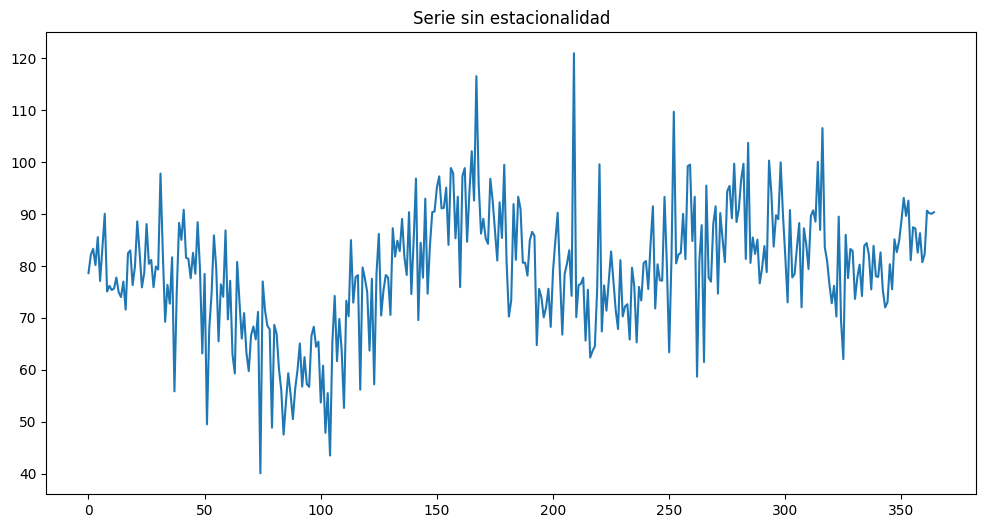

In [209]:
serie_desestacionalizada = res.trend + res.resid
plt.figure(figsize=(12, 6))
plt.plot(serie_desestacionalizada)
plt.title("Serie sin estacionalidad")
plt.show()

### Naive Forecasting

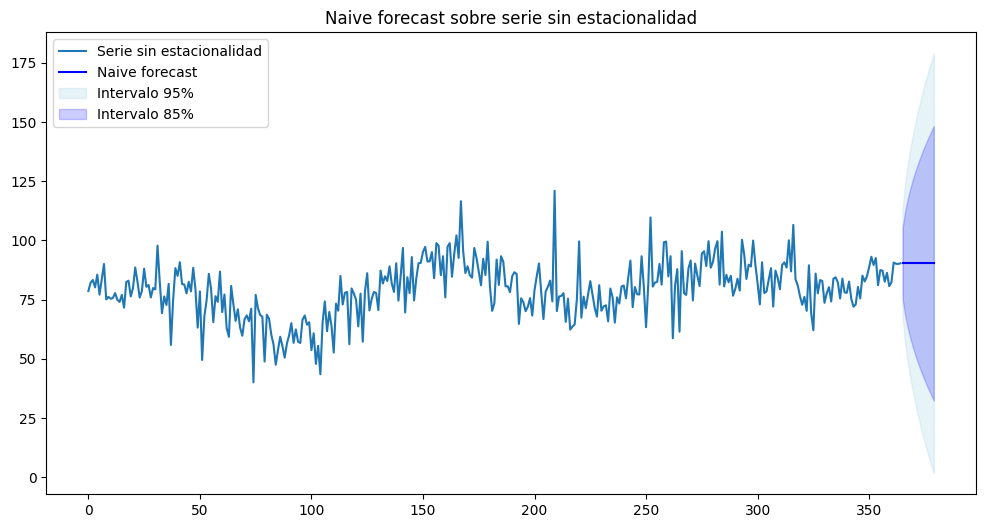

In [234]:
# Forecast naive: último valor repetido
def naive_forecast(series, steps=15):
    last_value = series.iloc[-1]
    forecast = pd.Series([last_value] * steps,
                         index=pd.RangeIndex(start=len(series), stop=len(series)+steps))
    return forecast

# --- PARTE 1: Forecast naive sobre la serie ajustada (sin estacionalidad)
steps = 15  # elijo predecir 15 dias
naive_pred = naive_forecast(serie_desestacionalizada, steps=steps)

# Estimación de la incertidumbre (std de residuos naive)
residuals = serie_desestacionalizada.diff().dropna()
residual_std = residuals.std()

# Intervalo de confianza 95% y 85%
# Crecimiento de la varianza con el horizonte (asumiendo error acumulado)
# Valores críticos z para intervalos de confianza
z_95 = norm.ppf(0.975)  # 97.5% para intervalo bilateral 95%
z_80 = norm.ppf(0.900)  # 90.0% para intervalo bilateral 80%

# Intervalos de confianza 95% y 80%
conf_int_upper_95 = naive_pred.values + z_95 * residual_std * np.sqrt(np.arange(1, steps + 1))
conf_int_lower_95 = naive_pred.values - z_95 * residual_std * np.sqrt(np.arange(1, steps + 1))
conf_int_upper_80 = naive_pred.values + z_80 * residual_std * np.sqrt(np.arange(1, steps + 1))
conf_int_lower_80 = naive_pred.values - z_80 * residual_std * np.sqrt(np.arange(1, steps + 1))

plt.figure(figsize=(12, 6))
plt.plot(serie_desestacionalizada, label="Serie sin estacionalidad")
plt.plot(naive_pred, label="Naive forecast", color="blue")
plt.fill_between(naive_pred.index, conf_int_lower_95, conf_int_upper_95,
                 color="lightblue", alpha=0.3, label="Intervalo 95%")
plt.fill_between(naive_pred.index, conf_int_lower_80, conf_int_upper_80,
                 color="blue", alpha=0.2, label="Intervalo 85%")
plt.title("Naive forecast sobre serie sin estacionalidad")
plt.legend()
plt.show()

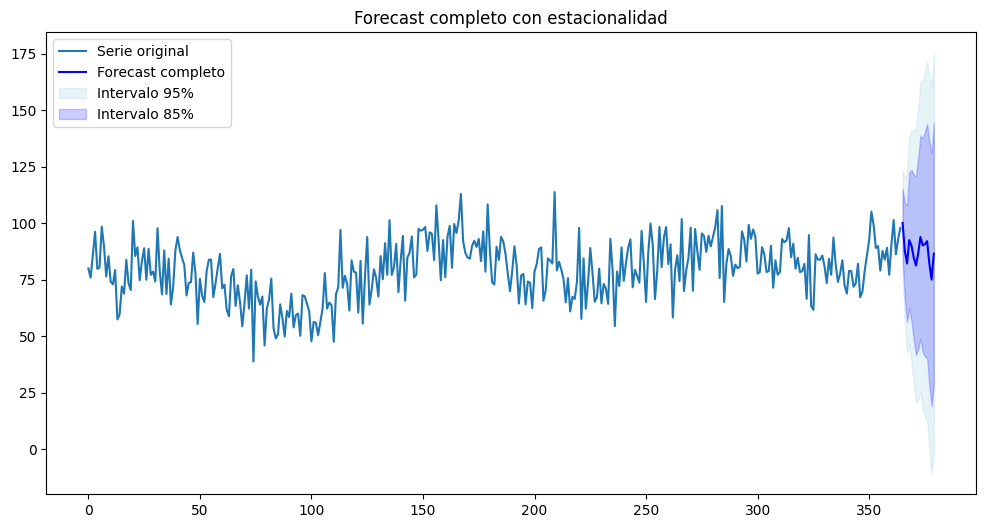

In [235]:
# Repetimos el patrón estacional
seasonal_pattern = res.seasonal[-periodo:]  # Último periodo
seasonal_future = np.resize(seasonal_pattern, 15)

# Forecast final = naive + estacionalidad futura
forecast_final = naive_pred.values + seasonal_future

# Calculo los nuevos intervalos con estacionalidad
conf_int_upper_95_final = conf_int_upper_95 + seasonal_future
conf_int_lower_95_final = conf_int_lower_95 + seasonal_future
conf_int_upper_80_final = conf_int_upper_80 + seasonal_future
conf_int_lower_80_final = conf_int_lower_80 + seasonal_future

plt.figure(figsize=(12, 6))
plt.plot(serie_pd, label="Serie original")
plt.plot(pd.Series(forecast_final, index=naive_pred.index), label="Forecast completo", color="blue")
plt.fill_between(naive_pred.index, conf_int_lower_95_final, conf_int_upper_95_final,
                 color="lightblue", alpha=0.3, label="Intervalo 95%")
plt.fill_between(naive_pred.index, conf_int_lower_80_final, conf_int_upper_80_final,
                 color="blue", alpha=0.2, label="Intervalo 85%")
plt.title("Forecast completo con estacionalidad")
plt.legend()
plt.show()
